
<div style="border-radius:10px;
            border : #015a2c solid;
            background-color:#D7D9DB;
           font-size:110%;
           letter-spacing:0.5px;
            text-align: center">
​
<center><h1 style="padding: 25px 0px; color:#015a4c; font-weight: bold; font-family: Cursive">
Amit Project for Data Science Module <br><br>💡💡💡💡💡 <br><br> DEPI_BS_DS_R3  </h1></center>
<center><h3 style="padding-bottom: 25px; color:#025b2c; font-weight: bold; font-style:italic; font-family: Cursive">
Using Project: Trip data Ford go bike  </h3></center>     
​
</div>

# Part I - (Dataset Exploration for Ford GoBike)

### worked by (Your Name/2025 )

## Introduction

.

> **Let's introduce our dataset:**


======================================

.

**This data set information was produced from `Ford GoBike` System** the information in it talked about individual rides that were made in a bike-sharing system for covering San Francisco Bay area.** 

.




> ## And here are the main exploring questions 



   **==================================================**



- What is the structure of your dataset?


- What are the main interesting features in the dataset?


- What features in the dataset supported my investigation for these interesting features?




.

> ### Also here are the investigative questions classified into three types



   **================================================**
   
   


###  <a href='#011'> Univariate Exploration</a> 

- <a href='#1'> 1 ) . What is the distribution of `User type`?</a>  
- <a href='#2'> 2 ) . What is the distribution for the `bike share users on all Trips`?</a>  
- <a href='#3'> 3 ) . What is the distribution for users' `ages`?</a>  
- <a href='#4'> 4 ) . Do the users' ages have `outlier` values?</a>
- <a href='#5'> 5 ) . What is the distribution for the trip duration in `minutes`? </a>
- <a href='#6'> 6) . What is the distribution for `member_gender`? </a>
- <a href='#7'> 7) . What is the distribution for the trip duration in `Hours`?  </a>




##  <a href='#111'> Bivariate Exploration</a> 


- <a href='#8'> 8 ) . What the `average duration` of trip for the categories of `user type`? </a>
- <a href='#9'> 9 ) . How long is the duration of the trip for `each gender` in `minutes`? </a>
- <a href='#10'> 10 ) . How long is the duration of the trip for each `user_type` in `minutes`?  </a>
- <a href='#11'> 11 ) . How the user distribution depending on their `Age` and `user_type` ?</a>
- <a href='#12'>12 ). How the user distribution depending on their `Age` and `member_gender` ?  </a>


##  <a href='#1111'> Multivariate Exploration</a> 


- <a href='#13'> 13 ) . What is the Correlation between `each` variable in the dataset?</a>  
- <a href='#14'> 14 ) . What is the Correlation between `specific numeric variables` in the dataset?</a>  
- <a href='#15'> 15 ) . What is the  Correlation between `data_stat` variables in the dataset?</a>  


##  <a href='#1100'> Conclusions </a> 





# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Import Libraries</p>

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt

import seaborn as sb

%matplotlib inline

In [2]:
# Load my dataset using pandas Dataframe

df = pd.read_csv('fordgobike-tripdataFor201902.csv')

In [3]:
# here we make overview in high-level for data shape and composition

df.shape

(183416, 16)

In [4]:
## check each var  datatype 

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 183416 entries, 0 to 183415
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183416 non-null  int64  
 1   start_time               183416 non-null  str    
 2   end_time                 183416 non-null  str    
 3   start_station_id         183219 non-null  float64
 4   start_station_name       183219 non-null  str    
 5   start_station_latitude   183416 non-null  float64
 6   start_station_longitude  183416 non-null  float64
 7   end_station_id           183219 non-null  float64
 8   end_station_name         183219 non-null  str    
 9   end_station_latitude     183416 non-null  float64
 10  end_station_longitude    183416 non-null  float64
 11  bike_id                  183416 non-null  int64  
 12  user_type                183416 non-null  str    
 13  member_birth_year        175151 non-null  float64
 14  member_gender  

In [5]:
## I display 15 rows to understand the content values more 

df.head(15)

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,32:10.1,01:56.0,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,53:21.8,42:03.1,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,13:13.2,24:08.1,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,54:26.0,02:36.8,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,54:18.5,20:44.1,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes
5,1793,49:58.6,19:51.8,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,-122.405950,5200,Subscriber,1959.0,Male,No
6,1147,55:35.1,14:42.6,300.0,Palm St at Willow St,37.317298,-121.884995,312.0,San Jose Diridon Station,37.329732,-121.901782,3803,Subscriber,1983.0,Female,No
7,1615,41:06.8,08:02.8,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6329,Subscriber,1989.0,Male,No
8,1570,41:48.8,07:59.7,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6548,Subscriber,1988.0,Other,No
9,1049,49:47.7,07:17.0,19.0,Post St at Kearny St,37.788975,-122.403452,121.0,Mission Playground,37.759210,-122.421339,6488,Subscriber,1992.0,Male,No


In [6]:
# descriptive statistics for numeric variables
df.describe()

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,183416.000000,183219.000000,183416.000000,183416.000000,183219.000000,183416.000000,183416.000000,183416.000000,175151.000000
mean,726.067311,138.590365,37.771221,-122.352661,136.249401,37.771425,-122.352247,4472.890260,1984.806504
std,1794.371831,111.778938,0.099586,0.117100,111.514916,0.099494,0.116677,1664.386068,10.116589
min,61.000000,3.000000,37.317298,-122.453705,3.000000,37.317298,-122.453705,11.000000,1878.000000
25%,325.000000,47.000000,37.770083,-122.412408,44.000000,37.770407,-122.411726,3777.000000,1980.000000
50%,514.000000,104.000000,37.780760,-122.398285,100.000000,37.781010,-122.398279,4958.000000,1987.000000
75%,796.000000,239.000000,37.797280,-122.286533,235.000000,37.797320,-122.288045,5502.000000,1992.000000
max,85444.000000,398.000000,37.880222,-121.874119,398.000000,37.880222,-121.874119,6645.000000,2001.000000




> ### What is the structure of your dataset?




- The structure of the dataset contains  16 columns and 183416 rows.
 
 
- Most variables are ...... in nature , and here are **dtypes summary :**

        - object(7)
        - int64(2)
        - float64(7)
        



> ### What are the main interesting features in the dataset?




 **We got three main feature areas which are :**
 
 
 
 
-  User characteristics such as user type, member gender, and birth year.

 
 
-  Trip characteristics such as trip duration and start/end stations.
 
  
 
  
- Bike-sharing usage characteristics such as bike share for all trips.
 




> ### What features in the dataset supported my investigation for these interesting features?


- User type, member gender, and member birth year help investigate the characteristics of the users



- Duration_sec, start_time, and end_time help investigate trip duration and usage patterns.



- Start and end station information and bike_share_for_all_trip help investigate bike-sharing usage and trip behavior.





- The trip-related features helped me analyze trip duration and travel patterns.



 - The station-related features helped me investigate where users start and end their trips.





##  More Exploring ideas to begin my investigation

In [8]:
#This code for describing statistical data ideas in a more organized and readable table
df.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
duration_sec,183416.0,726.07,1794.37,61.00,325.00,514.00,796.00,85444.00
start_station_id,183219.0,138.59,111.78,3.00,47.00,104.00,239.00,398.00
start_station_latitude,183416.0,37.77,0.10,37.32,37.77,37.78,37.80,37.88
start_station_longitude,183416.0,-122.35,0.12,-122.45,-122.41,-122.40,-122.29,-121.87
end_station_id,183219.0,136.25,111.51,3.00,44.00,100.00,235.00,398.00
end_station_latitude,183416.0,37.77,0.10,37.32,37.77,37.78,37.80,37.88
end_station_longitude,183416.0,-122.35,0.12,-122.45,-122.41,-122.40,-122.29,-121.87
bike_id,183416.0,4472.89,1664.39,11.00,3777.00,4958.00,5502.00,6645.00
member_birth_year,175151.0,1984.81,10.12,1878.00,1980.00,1987.00,1992.00,2001.00


In [9]:
# display the information about each column

df.isnull().sum()

duration_sec                  0
start_time                    0
end_time                      0
start_station_id            197
start_station_name          197
start_station_latitude        0
start_station_longitude       0
end_station_id              197
end_station_name            197
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8265
member_gender              8265
bike_share_for_all_trip       0
dtype: int64

## <mark>The above result show some missing values exist in some columns So let's display them </mark>

In [10]:
#yOUR CODES
df[df.isnull().any(axis=1)]

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
1,42521,53:21.8,42:03.1,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
13,915,49:06.1,04:21.9,252.0,Channing Way at Shattuck Ave,37.865847,-122.267443,244.0,Shattuck Ave at Hearst Ave,37.873676,-122.268487,5101,Subscriber,NaN,NaN,No
28,650,43:27.5,54:18.5,258.0,University Ave at Oxford St,37.872355,-122.266447,263.0,Channing Way at San Pablo Ave,37.862827,-122.290231,4784,Customer,NaN,NaN,No
53,3418,41:16.4,38:14.4,11.0,Davis St at Jackson St,37.797280,-122.398436,11.0,Davis St at Jackson St,37.797280,-122.398436,319,Customer,NaN,NaN,No
65,926,17:05.9,32:32.7,13.0,Commercial St at Montgomery St,37.794231,-122.402923,81.0,Berry St at 4th St,37.775880,-122.393170,2951,Subscriber,NaN,NaN,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183354,449,35:07.7,42:36.9,244.0,Shattuck Ave at Hearst Ave,37.873676,-122.268487,253.0,Haste St at College Ave,37.866418,-122.253799,5430,Customer,NaN,NaN,No
183356,795,25:50.4,39:06.0,368.0,Myrtle St at Polk St,37.785434,-122.419622,125.0,20th St at Bryant St,37.759200,-122.409851,5400,Subscriber,NaN,NaN,No
183363,673,12:24.4,23:37.6,75.0,Market St at Franklin St,37.773793,-122.421239,133.0,Valencia St at 22nd St,37.755213,-122.420975,5166,Customer,NaN,NaN,No
183371,196,08:38.6,11:54.9,58.0,Market St at 10th St,37.776619,-122.417385,75.0,Market St at Franklin St,37.773793,-122.421239,2395,Customer,NaN,NaN,No




> ## <mark>The result above shows many missing data </mark>



###  To fix this issue You will fill these values with median  for numeric and  mode for categorical

In [11]:
# trying to fill missing values in my datset using for loop 



# Fill missing values in numeric columns with median
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

# Fill missing values in categorical columns with mode
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])



C:\Users\SHARKS\AppData\Local\Temp\ipykernel_12928\2469117639.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [12]:
#check the Nulls 
df.isnull().sum()

duration_sec               0
start_time                 0
end_time                   0
start_station_id           0
start_station_name         0
start_station_latitude     0
start_station_longitude    0
end_station_id             0
end_station_name           0
end_station_latitude       0
end_station_longitude      0
bike_id                    0
user_type                  0
member_birth_year          0
member_gender              0
bike_share_for_all_trip    0
dtype: int64

### **And with a proper category for other (member gender)**

In [13]:
##  still got a missing value in the member_gender, so let's explore this column more 

df['member_gender'].head(15)

0       Male
1       Male
2       Male
3      Other
4       Male
5       Male
6     Female
7       Male
8      Other
9       Male
10    Female
11      Male
12      Male
13      Male
14      Male
Name: member_gender, dtype: str

In [14]:
# fill  dataset with missing values.
    
df['member_gender'] = df['member_gender'].fillna('other')

In [16]:
# print(gbf.member_gender.head(15))
df['member_gender'].head(15)

0       Male
1       Male
2       Male
3      Other
4       Male
5       Male
6     Female
7       Male
8      Other
9       Male
10    Female
11      Male
12      Male
13      Male
14      Male
Name: member_gender, dtype: str

In [17]:
## check my result above 
df.isnull().sum()

duration_sec               0
start_time                 0
end_time                   0
start_station_id           0
start_station_name         0
start_station_latitude     0
start_station_longitude    0
end_station_id             0
end_station_name           0
end_station_latitude       0
end_station_longitude      0
bike_id                    0
user_type                  0
member_birth_year          0
member_gender              0
bike_share_for_all_trip    0
dtype: int64

> ## <mark>The result above shows that we deal with all missing data </mark>

### Now let's check duplicate value

In [18]:
##  check duplicate in dataset

df.duplicated().sum()

np.int64(4)

> ##If Not significant duplicated , so won't clean it 


### Now let's check the category columns to make more cleaning dataset 

In [19]:
### check the category columns that included object
df.select_dtypes(include='object').columns

C:\Users\SHARKS\AppData\Local\Temp\ipykernel_12928\4026129391.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['start_time', 'end_time', 'start_station_name', 'end_station_name',
       'user_type', 'member_gender', 'bike_share_for_all_trip'],
      dtype='str')

 > ## From all previous results above I found  :
 
 
 
 **=========================================================**
 
 

> 1 ) **unique Value** as in ((`member_gender`)) : Not significant , so won't clean it



> 2 ) **Incorrect data type** as in (( `user_type` &&	`member_gender`)) :  significant change , so I need to clean it.


> 3 ) **Good factor** for marketing work as in ((`member_birth_year`)) : so I need to clean it.

In [20]:
##  step  2 ) Incorrect data type as in (( `user_type` &&	`member_gender`)) :  significant change , so  need to clean it.
df['user_type'] = df['user_type'].astype('category')
df['member_gender'] = df['member_gender'].astype('category')


In [21]:
## check your work 

df[['user_type','member_gender']].dtypes

user_type        category
member_gender    category
dtype: object

In [22]:
## step 3 ) Good factor for marketing work as in ((`member_birth_year`)) : so need to clean it.
## To know the target audience's age and serve on them

# create a column for users' age depending on the current year

df['age'] = 2019 - df['member_birth_year']

In [23]:
## check your work 

df['age'].head()

0    35.0
1    32.0
2    47.0
3    30.0
4    45.0
Name: age, dtype: float64

In [24]:
## change the new column age data type from float to int
df['age'] = df['age'].astype('int')


In [25]:
## create a function to know the average users ages
df['age'].dtype

dtype('int64')

In [26]:
## another important factor to offer  marketing services is the trip duration time 

## need to change the time from second to minute to be more usable

df['duration_min'] = df['duration_sec'] / 60


In [27]:
## I need to change the time from second to Houre  to be more usable

df['duration_hr'] = df['duration_sec'] / 3600

In [28]:
## check your work 
df[['duration_sec','duration_min','duration_hr']].head()

,duration_sec,duration_min,duration_hr
0,52185,869.750000,14.495833
1,42521,708.683333,11.811389
2,61854,1030.900000,17.181667
3,36490,608.166667,10.136111
4,1585,26.416667,0.440278



# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Univariate Exploration</p>
# <a id="011"> Univariate Exploration</a>



> In this section, investigate distributions of individual variables. If
you see unusual points or outliers, take a deeper look to clean things up
and prepare yourself to look at relationships between variables.




# <a id="1"> 1 ) . What is the distribution for User type?</a>

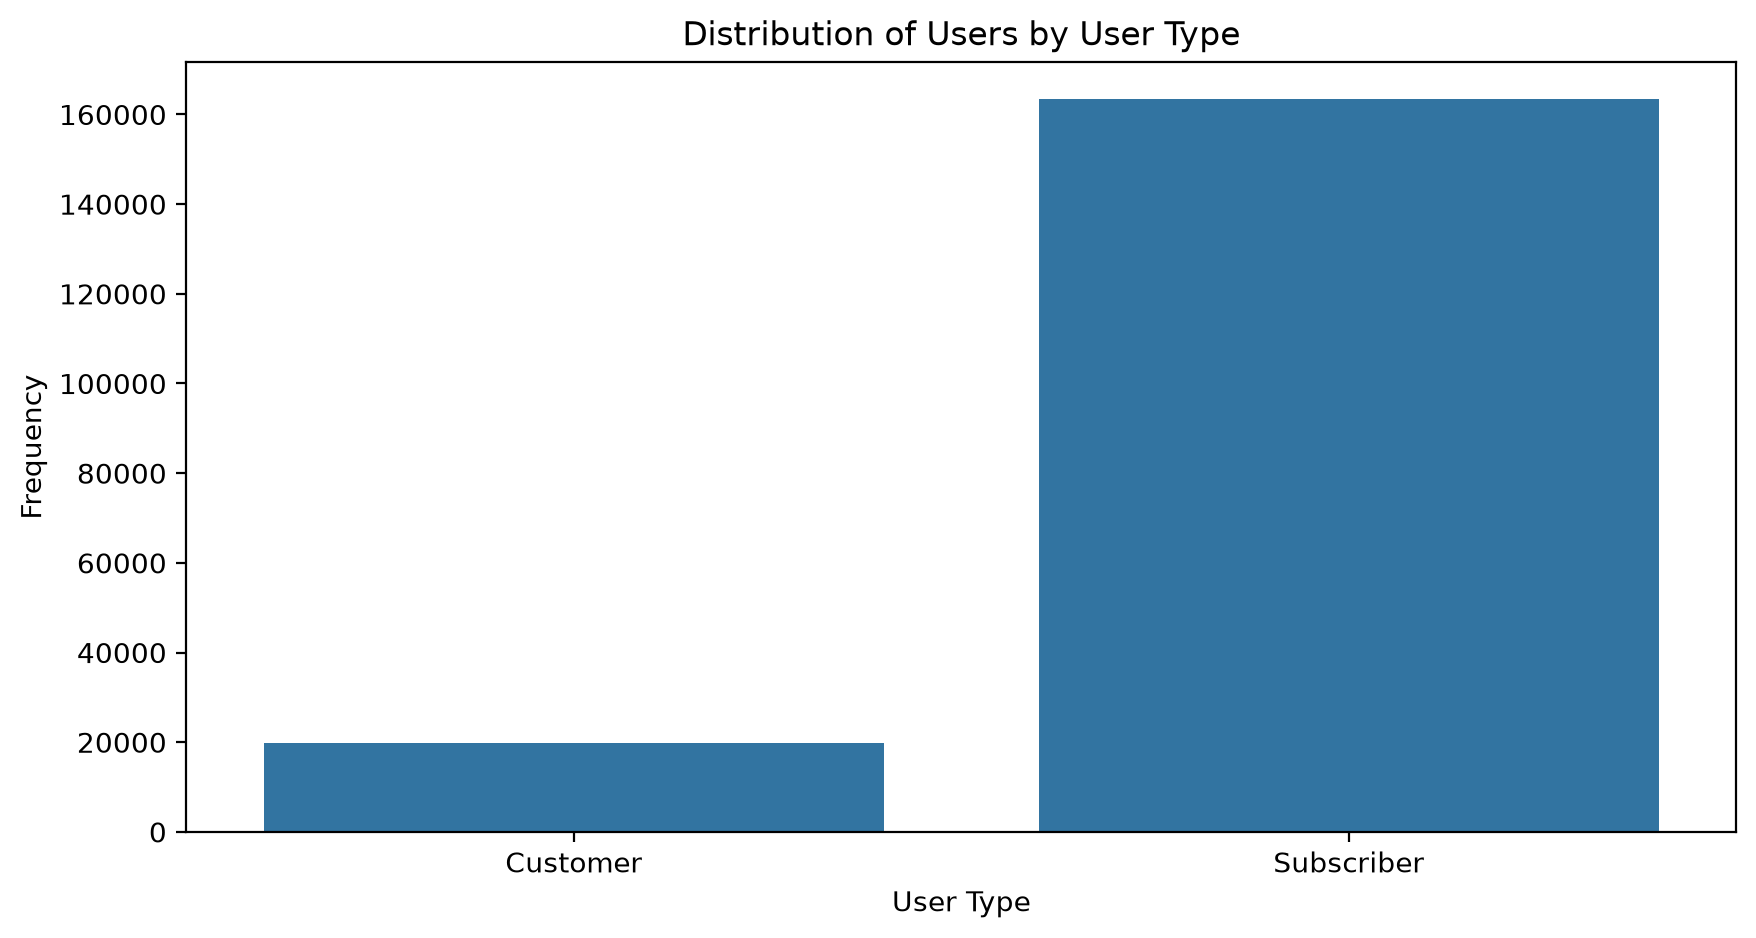

In [29]:
## I will import seaborn library to support me in making visualizations 

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5), dpi=200)

sns.countplot(data=df, x='user_type')

plt.xlabel('User Type')
plt.ylabel('Frequency')
plt.title("Distribution of Users by User Type")

plt.show()

> ### <mark>Your analsys and exploration here </mark>

# <a id="2"> 2 ) What is the distribution for the bike share users on all Trips?</a>

 ### <mark>Your analsys and exploration here </mark>

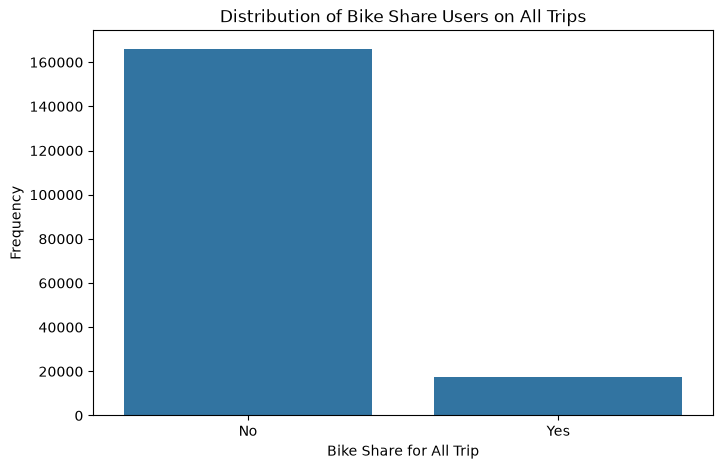

In [30]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='bike_share_for_all_trip')

plt.xlabel('Bike Share for All Trip')
plt.ylabel('Frequency')
plt.title('Distribution of Bike Share Users on All Trips')

plt.show()

# <a id="3"> 3 ) What is the distribution for users' ages? </a>

> ### <mark>Your analsys and exploration here </mark>

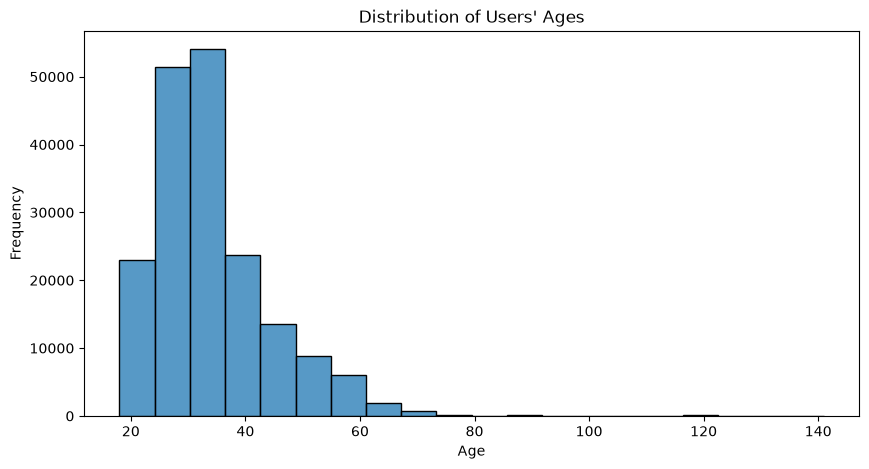

In [31]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='age', bins=20)

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title("Distribution of Users' Ages")

plt.show()


# <a id="4">  4 ) . Do the users' ages have outlier values?</a>


> ### <mark>Your analsys and exploration here </mark>

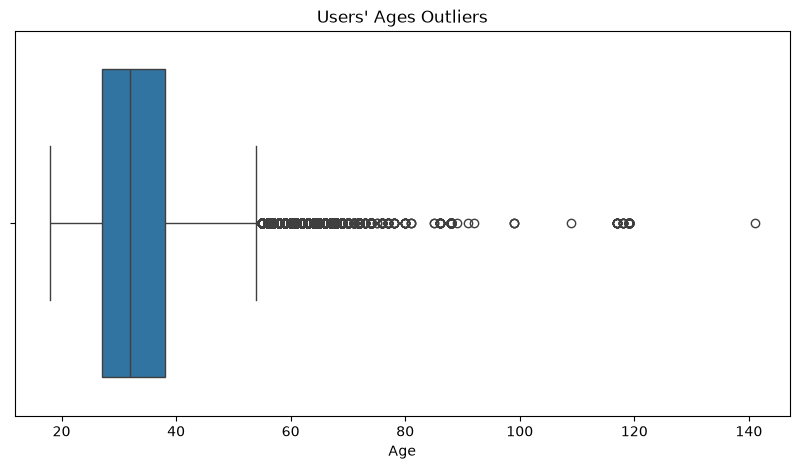

In [32]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='age')

plt.xlabel('Age')
plt.title("Users' Ages Outliers")

plt.show()

# <a id="5">  5 ) . What is the distribution for the trip duration in minutes? </a>

In [33]:
## Review the statistic for trip duration in minutes

df['duration_min'].describe()

count    183416.000000
mean         12.101122
std          29.906197
min           1.016667
25%           5.416667
50%           8.566667
75%          13.266667
max        1424.066667
Name: duration_min, dtype: float64

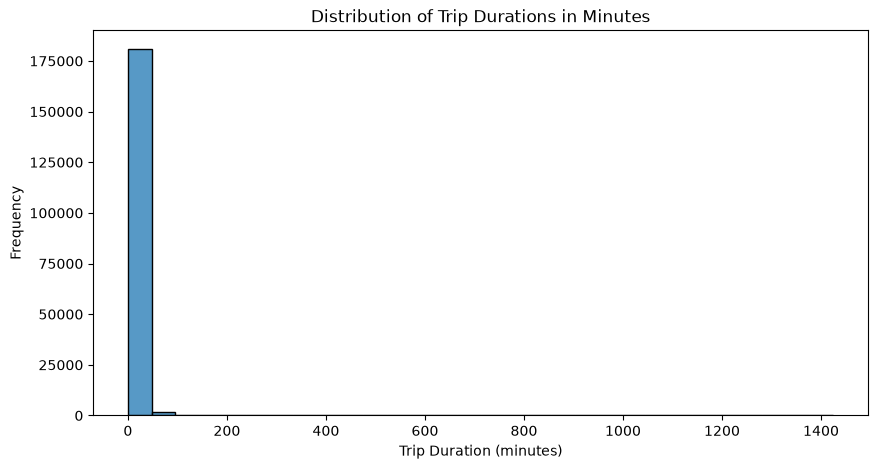

In [34]:
# Make visualization to easy get insight
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='duration_min', bins=30)
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Frequency')
plt.title("Distribution of Trip Durations in Minutes")
plt.show()

> ### <mark>Your analsys and exploration here </mark>

The trip duration is right-skewed, with most trips being relatively short and a small number of trips having much longer durations.


# <a id="6"> 6 ) . What is the distribution for member_gender?</a>

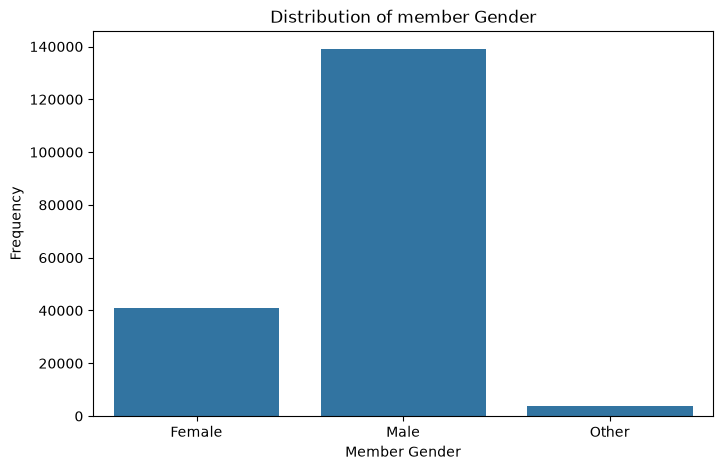

In [36]:
# Make visualization to easy get insight
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='member_gender')
plt.xlabel('Member Gender')
plt.ylabel('Frequency')
plt.title("Distribution of member Gender")
plt.show()

> ### <mark>Your analsys and exploration here </mark>

Male users represent the largest group, followed by female users, while other genders represent a much smaller proportion.

# <a id="7">    7 )  . What is the distribution for the trip duration in Hours?  </a>

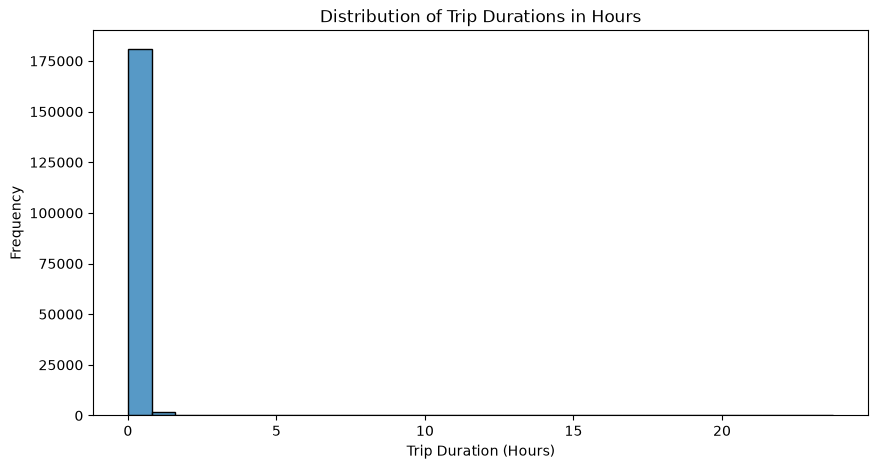

In [39]:
# Make visualization to easy get insight
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='duration_hr', bins=30)
plt.xlabel('Trip Duration (Hours)')
plt.ylabel('Frequency')
plt.title("Distribution of Trip Durations in Hours")
plt.show()

> ### <mark>Your analsys and exploration here </mark>

The distribution shows that most trips lasted less than one hour, while a small number of trips had much longer durations.

### The variables distribution:


> The distribution of duration present that most of the trips were less than 30 minutes ( we can notice that from the minutes and the hour charts )


> And the Age distribution is ( left Skewed ) as most users age are  22 - 39


> Most users are subscribers, not Customers and  Males as shown in the charts above.



### Were there any interesting and outliers 


- We got Age outliers for for more than 100 .



- The distribution of duration was strange where the minutes and the hour charts were 30 minutes or less.

# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Bivariate Exploration</p>
# <a id="111"> Bivariate Exploration</a>

Now let's investigate relationships between pairs of variables in our data.

# <a id="8"> 8) . What the average duration of trip for the categories of user type?</a>

In [43]:
# Distribution of Age by user types
df.groupby('user_type')['duration_min'].mean()


user_type
Customer      23.874417
Subscriber    10.670888
Name: duration_min, dtype: float64

# Make visualization to easy get insight


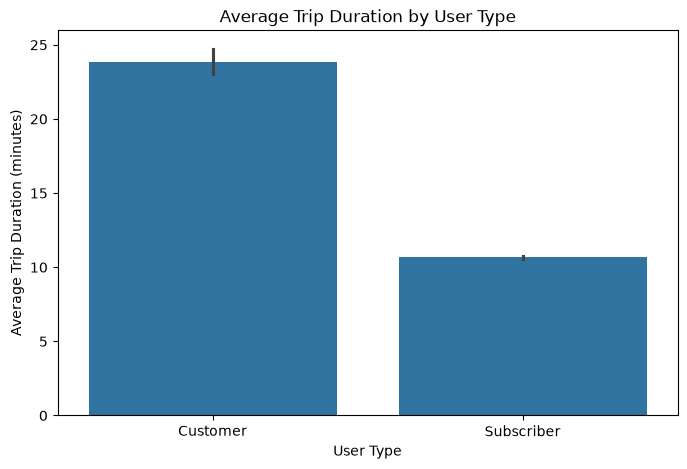

In [44]:
plt.figure(figsize=(8,5))

sns.barplot(data=df, x='user_type', y='duration_min')

plt.xlabel('User Type')
plt.ylabel('Average Trip Duration (minutes)')
plt.title('Average Trip Duration by User Type')

plt.show()

> ### <mark>Your analsys and exploration here </mark>

Customers have a higher average trip duration than Subscribers.

# <a id="9">    9 ) . How long is the duration of the trip for each gender in minutes?  </a>

In [45]:
# Make visualization to easy get insight

# ------------------------Duration distribution by member gender
df.groupby('member_gender')['duration_min'].mean()


member_gender
Female    12.984506
Male      11.722903
Other     16.608589
Name: duration_min, dtype: float64

# Make visualization to easy get insight


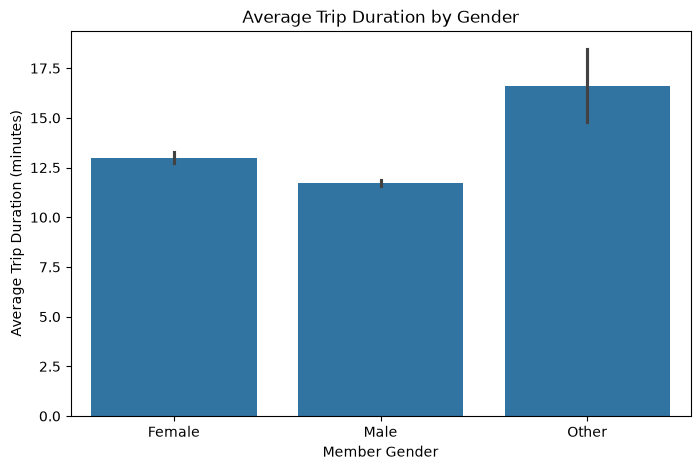

In [47]:
plt.figure(figsize=(8,5))

sns.barplot(data=df, x='member_gender', y='duration_min')

plt.xlabel('Member Gender')
plt.ylabel('Average Trip Duration (minutes)')
plt.title('Average Trip Duration by Gender')

plt.show()

> ### <mark>Your analsys and exploration here </mark>

The average trip duration varies between the different genders.

# <a id="10 "> 10 ) . How long is the duration of the trip for each user_type in minutes?  </a>

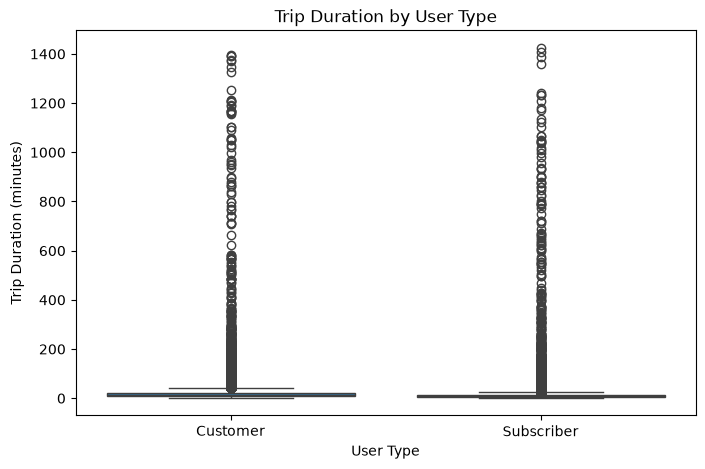

In [48]:

# Make visualization to easy get insight

plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='user_type', y='duration_min')

plt.xlabel('User Type')
plt.ylabel('Trip Duration (minutes)')
plt.title('Trip Duration by User Type')

plt.show()

> ### <mark>Your analsys and exploration here </mark>

Customers have longer trip durations than Subscribers.
The distribution also shows that there are some long trips for both user types.

# <a id="11">  11 ) . How the user distribution depending on their Age and user_type ? </a>

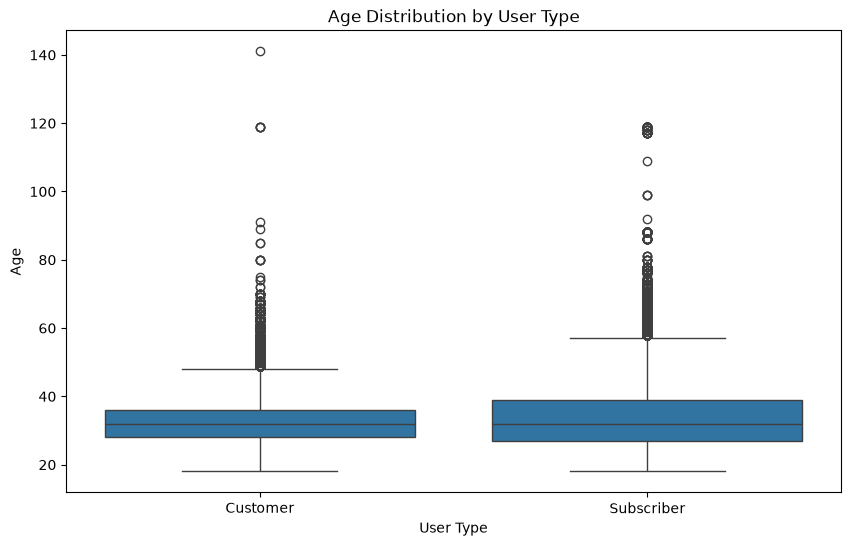

In [49]:

# Make visualization to easy get insight
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x='user_type', y='age')

plt.xlabel('User Type')
plt.ylabel('Age')
plt.title('Age Distribution by User Type')

plt.show()

> ### <mark>Your analsys and exploration here </mark>

The age distribution is different between Customers and Subscribers.
Most users are adults, and Subscribers represent the larger group of users.

#  <a id="12"> 12 ). How the user distribution depending on their Age and member_gender ?</a>

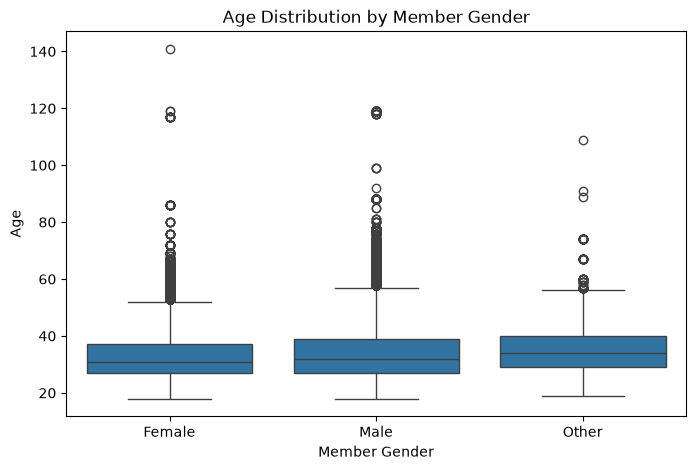

In [50]:
# Make visualization to easy get insight

plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='member_gender', y='age')

plt.xlabel('Member Gender')
plt.ylabel('Age')
plt.title('Age Distribution by Member Gender')

plt.show()

> ### <mark>Your analsys and exploration here </mark>

The age distribution varies across different genders.
Most users are between 22 and 39 years old, with Male users representing the largest group.

### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

> Most users are between 22 and 39 years old. Subscribers are the largest user group, and Male users represent the largest gender group. Customers tend to have longer trip durations than Subscribers.


### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

> An interesting relationship is that user type is related to trip duration. Customers have a higher average trip duration than Subscribers. Trip duration is also generally short, with most trips lasting less than 30 minutes.

# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Multivariate Exploration</p>
# <a id="1111"> Multivariate Exploration </a>

> Create plots of three or more variables to investigate your data even
further. Make sure that your investigations are justified, and follow from
your work in the previous sections.

In [51]:
## check your work 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 183416 entries, 0 to 183415
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   duration_sec             183416 non-null  int64   
 1   start_time               183416 non-null  str     
 2   end_time                 183416 non-null  str     
 3   start_station_id         183416 non-null  float64 
 4   start_station_name       183416 non-null  str     
 5   start_station_latitude   183416 non-null  float64 
 6   start_station_longitude  183416 non-null  float64 
 7   end_station_id           183416 non-null  float64 
 8   end_station_name         183416 non-null  str     
 9   end_station_latitude     183416 non-null  float64 
 10  end_station_longitude    183416 non-null  float64 
 11  bike_id                  183416 non-null  int64   
 12  user_type                183416 non-null  category
 13  member_birth_year        183416 non-null  float64 
 14 


# <a id="13">  13 ) . What is the  Correlation between each variable in the dataset?</a>

In [53]:
corr=df.select_dtypes(include=np.number).corr()
corr

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year,age,duration_min,duration_hr
duration_sec,1.000000,-0.008681,0.010519,-0.037935,0.003030,0.010880,-0.038912,-0.006130,-0.002805,0.002805,1.000000,1.000000
start_station_id,-0.008681,1.000000,-0.188387,0.454964,0.336312,-0.177250,0.462474,-0.064604,0.111319,-0.111319,-0.008681,-0.008681
start_station_latitude,0.010519,-0.188387,1.000000,-0.677254,-0.177156,0.989970,-0.682663,0.050001,-0.074264,0.074264,0.010519,0.010519
start_station_longitude,-0.037935,0.454964,-0.677254,1.000000,0.475284,-0.681840,0.992410,-0.141779,0.121568,-0.121568,-0.037935,-0.037935
end_station_id,0.003030,0.336312,-0.177156,0.475284,1.000000,-0.195275,0.464670,-0.054533,0.109025,-0.109025,0.003030,0.003030
end_station_latitude,0.010880,-0.177250,0.989970,-0.681840,-0.195275,1.000000,-0.684222,0.049249,-0.074341,0.074341,0.010880,0.010880
end_station_longitude,-0.038912,0.462474,-0.682663,0.992410,0.464670,-0.684222,1.000000,-0.143522,0.122353,-0.122353,-0.038912,-0.038912
bike_id,-0.006130,-0.064604,0.050001,-0.141779,-0.054533,0.049249,-0.143522,1.000000,0.033960,-0.033960,-0.006130,-0.006130
member_birth_year,-0.002805,0.111319,-0.074264,0.121568,0.109025,-0.074341,0.122353,0.033960,1.000000,-1.000000,-0.002805,-0.002805
age,0.002805,-0.111319,0.074264,-0.121568,-0.109025,0.074341,-0.122353,-0.033960,-1.000000,1.000000,0.002805,0.002805


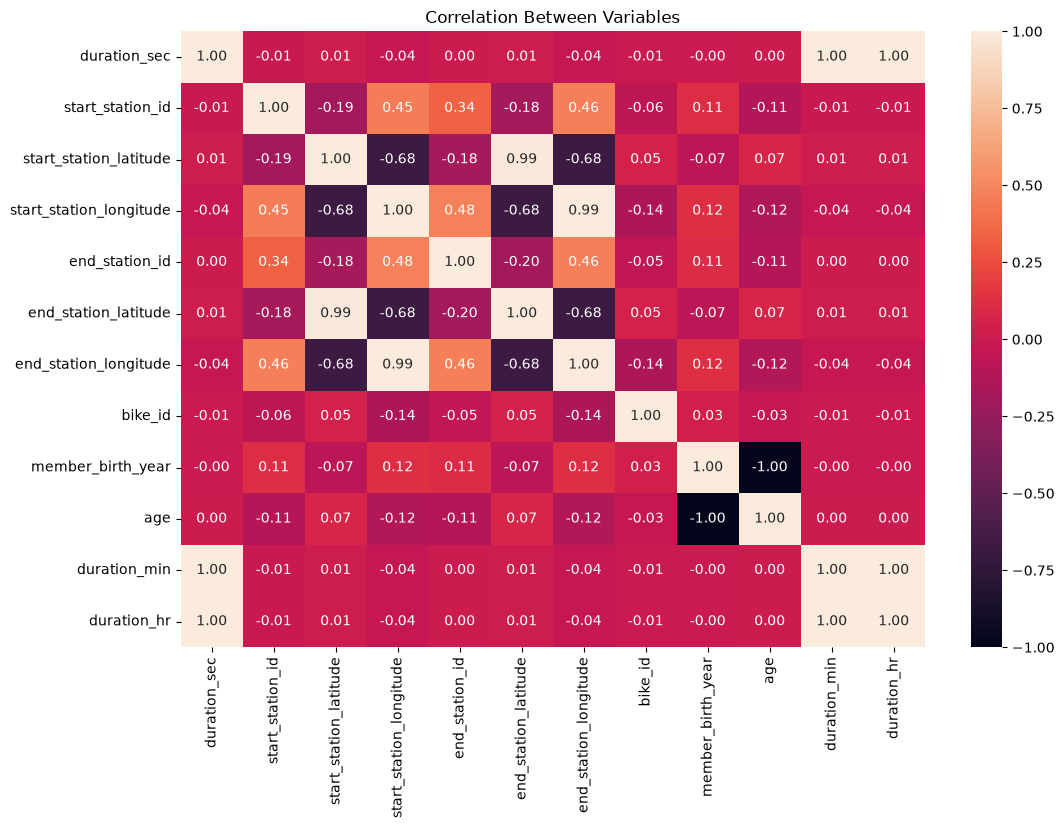

In [54]:
# Make visualization to easy get insight
plt.figure(figsize=(12,8))

sns.heatmap(corr, annot=True, fmt='.2f')

plt.title('Correlation Between Variables')

plt.show()



> ### <mark>Your analsys and exploration here </mark>

Example usage
- There is `no Correlation` for any variable with time ( `duration sec /minutes/hours`)


The correlation heatmap shows the relationships between the numerical variables. Some variables have strong positive or negative correlations, while most variables have weak correlations.


# <a id="14"> 14 )  .  What is the  Correlation between `specific numeric variables` in the dataset?</a>


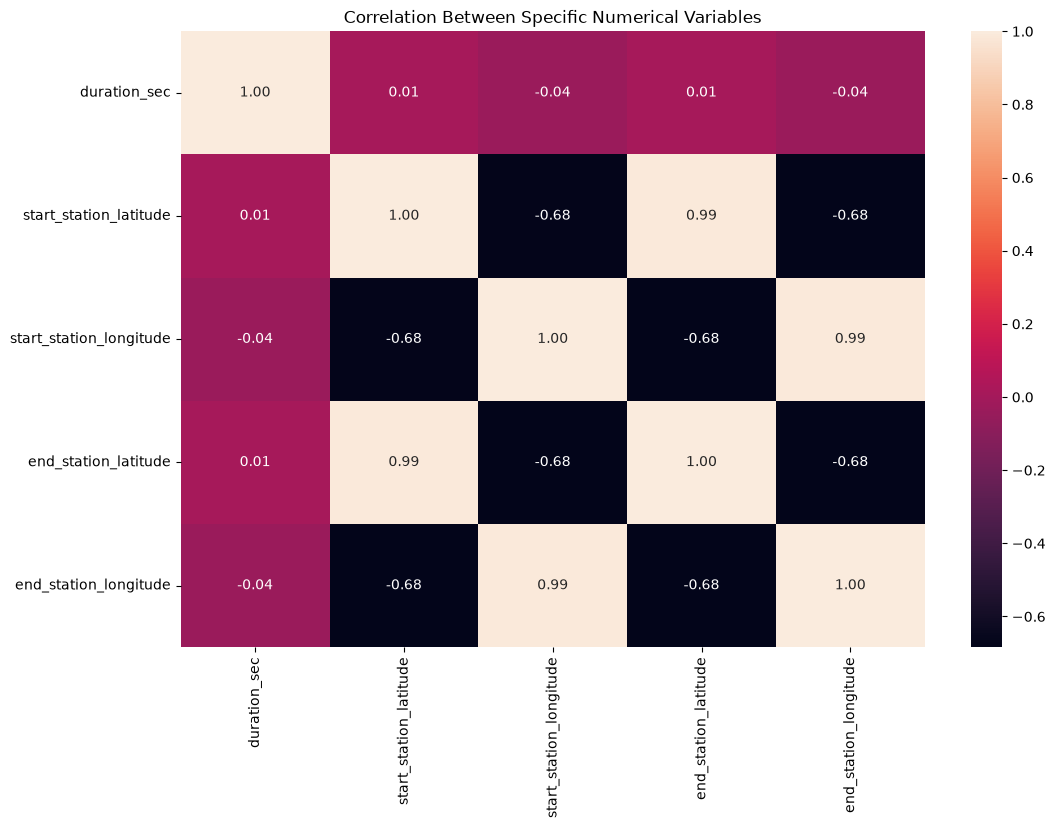

In [57]:
# Make visualization to easy get insight

specific_corr = df[['duration_sec', 'start_station_latitude',
                      'start_station_longitude', 'end_station_latitude',
                      'end_station_longitude']].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(specific_corr, annot=True, fmt='.2f')

plt.title('Correlation Between Specific Numerical Variables')

plt.show()



> ### <mark>Your analsys and exploration here </mark>

Example usage
- There is `no Correlation` for any variable with time ( `duration sec /minutes`)




- The selected variables have mostly weak correlations.





- Start/end station locations show the strongest correlations





# <a id="15">  15 ) What is the  Correlation between data_stat variables in the dataset?</a>


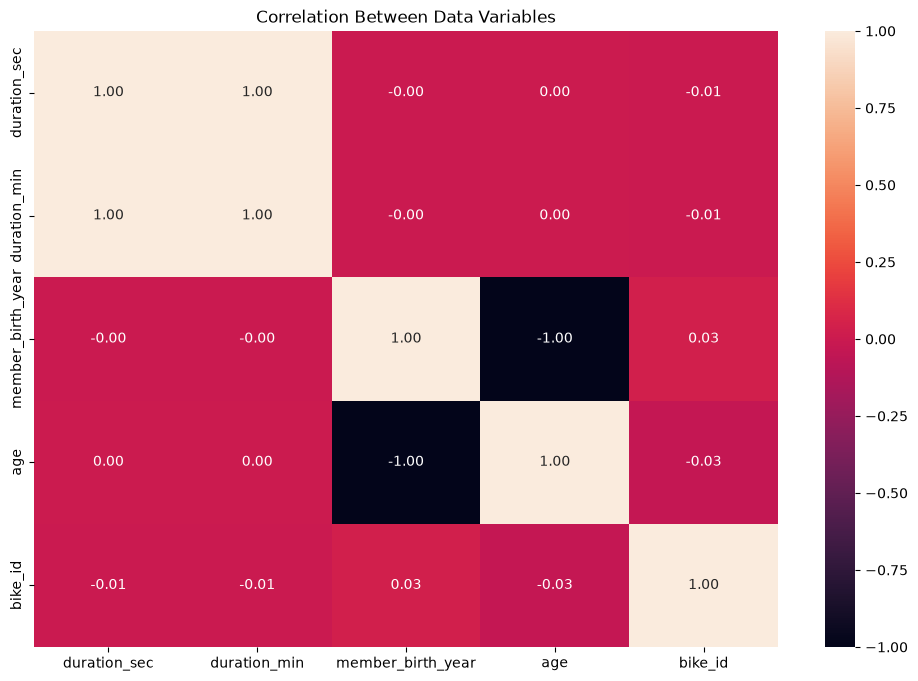

In [59]:

"""""This time I will use heatmap  to explain how Correlation between data_stat variables

in the dataset in more clear and specific percentage"""

# Make visualization to easy get insight

date_stat_corr = df[['duration_sec', 'duration_min',
                      'member_birth_year', 'age', 'bike_id']].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(date_stat_corr, annot=True, fmt='.2f')
plt.title('Correlation Between Data Variables')
plt.show()

> ### <mark>The above charts show how Correlation between specific numeric variables in the dataset using heatmap plots  </mark>



**Actually the `heat map`  display the above ideas in clear percentages**



- There is `no Correlation` for any variable with time ( `duration sec /minutes`)




- There is a `negative  Correlation` between  member_birth_year  and age which normal.




- There is `no significant Correlation` for any variable with `bike_id `



# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Conclusions</p>
# <a id="1100"> Conclusions </a>

#example
- Most users were Male.
- Most users were Subscribers rather than Customers.
- Most trips lasted less than 30 minutes.
- Most users were between 22 and 39 years old.
- Some age outliers were found, especially ages above 100.
- Trip duration has weak correlation with most numerical variables.




## limitation 
example
- We got missing data which we fix some of them .
- Some missing data were found and needed to be handled.
- Age outliers, especially ages above 100, may affect the analysis.
- The dataset covers a limited period, so the results may not represent all bike-sharing users.
